# 02 · Validating the Synthetic Data

**Purpose.** Confirm the generated panel behaves like a plausible telecom travel population before anything is fitted to it, and settle the one decision the modeling depends on: how to reconstruct the five behavioral states from observable quantities.

This is not exploratory analysis in the usual sense. The generating process is known, so nothing here is a discovery. Every check below either **validates the generator** or **produces a number the labeling rule needs**.

**Three questions**

1. **Does the panel look real?** Marginals, ratios and revenue concentration in ranges a telecom analyst would recognize.
2. **Is the label boundary readable from the data?** If `days_bought / days_traveled` is bimodal, the reduce/unchanged threshold reads off the shape instead of being picked arbitrarily.
3. **Is there enough price variation to estimate a response — per segment, not just overall?** A segment that never faced a price change cannot have its sensitivity estimated, and that has to be known before fitting, not after.

A failure in (1) means fixing parameters in notebook 01. A failure in (3) means changing the price-variation design. Neither is recoverable downstream.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data/synthetic")


def load(name):
    pq, csv = DATA / f"{name}.parquet", DATA / f"{name}.csv"
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"{name} not found in {DATA.resolve()} — run notebook 01 first.")


accounts = load("accounts")
macro = load("macro")
trips = load("trips")
ground_truth = load("ground_truth")   # validation only, never a model input

trips = trips.merge(accounts, on="account_id", how="left")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 9,
})
INK, ACCENT, MUTED = "#201e1d", "#1c4ed8", "#9a9694"

print(f"{len(accounts):,} accounts · {len(trips):,} trips · {macro.month.nunique()} months")

50,000 accounts · 94,440 trips · 24 months


---
## 1 · Does the panel look real?

### 1.1 Coverage and shape

The first thing to check is that the population is not uniformly active. Real travel is concentrated: most accounts never leave the country in a given year, and a small group travels constantly. If this panel shows everyone travelling a similar amount, the segmentation later will have nothing to separate.

accounts                                50,000.00
accounts that travelled                 29,312.00
share that travelled                         0.59
trips total                             94,440.00
trips per travelling account (median)        2.00
trips per travelling account (p95)          10.00
months                                      24.00


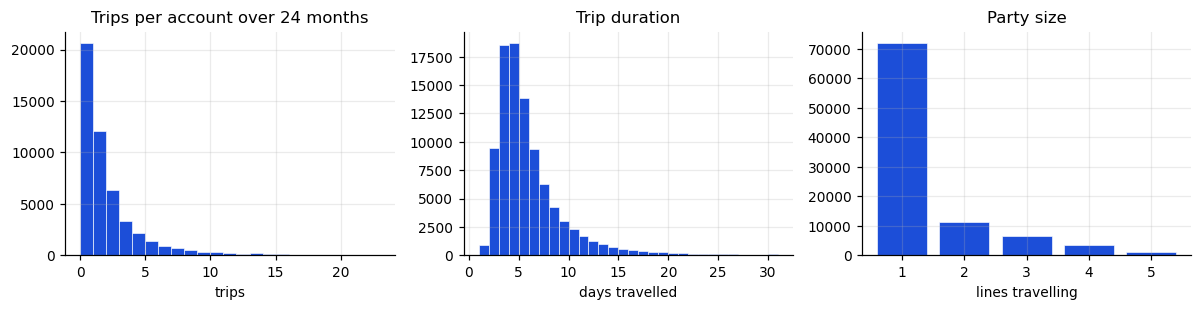

In [2]:
trips_per_account = trips.groupby("account_id").size()
all_accounts = accounts.set_index("account_id").index
trip_counts = trips_per_account.reindex(all_accounts, fill_value=0)

n_months = macro.month.nunique()
summary = pd.Series({
    "accounts": len(accounts),
    "accounts that travelled": (trip_counts > 0).sum(),
    "share that travelled": (trip_counts > 0).mean(),
    "trips total": len(trips),
    "trips per travelling account (median)": trip_counts[trip_counts > 0].median(),
    "trips per travelling account (p95)": trip_counts[trip_counts > 0].quantile(0.95),
    "months": n_months,
})
print(summary.to_string(float_format=lambda v: f"{v:,.2f}"))

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))

axes[0].hist(trip_counts, bins=range(0, int(trip_counts.quantile(0.995)) + 2),
             color=ACCENT, edgecolor="white", linewidth=0.4)
axes[0].set_title(f"Trips per account over {n_months} months")
axes[0].set_xlabel("trips")

axes[1].hist(trips["days_traveled"], bins=range(1, 32), color=ACCENT,
             edgecolor="white", linewidth=0.4)
axes[1].set_title("Trip duration")
axes[1].set_xlabel("days travelled")

party = trips["lines_traveling"].value_counts().sort_index()
axes[2].bar(party.index, party.values, color=ACCENT, edgecolor="white", linewidth=0.4)
axes[2].set_title("Party size")
axes[2].set_xlabel("lines travelling")

plt.tight_layout()
plt.show()

**What should be true here**

- A large share of accounts with zero trips — international travel is a minority behaviour.
- Trip duration right-skewed, business trips clustered short, leisure with a long tail.
- Party size dominated by 1, with a meaningful tail of household travel — that tail is where the `$5` additional-line economics live.

If duration or party size looks symmetric or flat, the generator parameters need adjusting before proceeding.

### 1.2 Business and consumer should behave differently

The entire pricing argument rests on these two groups responding differently. If they are indistinguishable in the raw data, the model has nothing to find and the segmentation will be noise.

Per trip
             trips  accounts  avg_days  avg_party  solo_share  no_purchase_rate  avg_revenue
is_business                                                                                 
consumer     40527     19667     7.247      1.567       0.641             0.127       76.410
business     53913      9645     4.183      1.286       0.858             0.070       42.869

Per account over the full window
             accounts  trips_per_account  revenue_per_account  revenue_p90
is_business                                                               
consumer        19667               2.06               157.45        352.0
business         9645               5.59               239.63        539.0


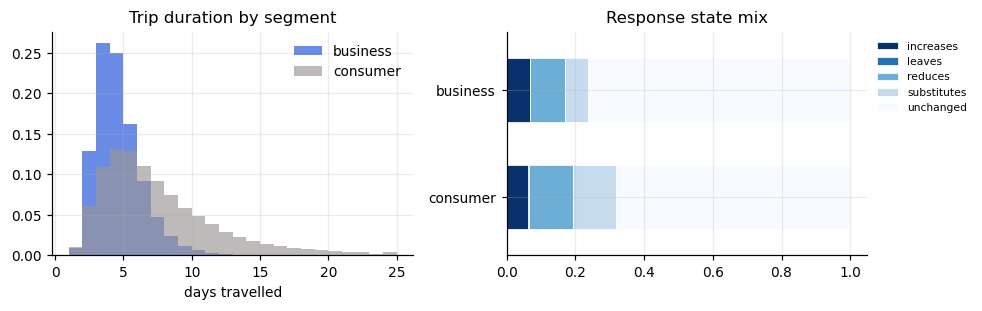

In [3]:
seg = trips.groupby("is_business").agg(
    trips=("trip_id", "size"),
    accounts=("account_id", "nunique"),
    avg_days=("days_traveled", "mean"),
    avg_party=("lines_traveling", "mean"),
    solo_share=("lines_traveling", lambda s: (s == 1).mean()),
    no_purchase_rate=("days_bought", lambda s: (s == 0).mean()),
    avg_revenue=("pass_revenue", "mean"),
).round(3)
seg.index = seg.index.map({False: "consumer", True: "business"})
print("Per trip")
print(seg.to_string())

# Per ACCOUNT is the unit a pricing decision is made on: business trips are
# smaller but far more frequent, so per-trip revenue understates the segment.
per_acct = (trips.groupby(["is_business", "account_id"])
            .agg(trips=("trip_id", "size"), revenue=("pass_revenue", "sum"))
            .groupby("is_business").agg(
                accounts=("trips", "size"),
                trips_per_account=("trips", "mean"),
                revenue_per_account=("revenue", "mean"),
                revenue_p90=("revenue", lambda s: s.quantile(0.90)),
            ).round(2))
per_acct.index = per_acct.index.map({False: "consumer", True: "business"})
print("\nPer account over the full window")
print(per_acct.to_string())

fig, axes = plt.subplots(1, 2, figsize=(9, 2.9))

for flag, label, color in [(True, "business", ACCENT), (False, "consumer", MUTED)]:
    sub = trips[trips.is_business == flag]
    axes[0].hist(sub["days_traveled"], bins=range(1, 26), alpha=0.65,
                 label=label, color=color, density=True)
axes[0].set_title("Trip duration by segment")
axes[0].set_xlabel("days travelled")
axes[0].legend(frameon=False)

state_mix = (trips.groupby("is_business")["state"]
             .value_counts(normalize=True).unstack().fillna(0))
state_mix.index = state_mix.index.map({False: "consumer", True: "business"})
state_mix.plot(kind="barh", stacked=True, ax=axes[1], width=0.6,
               colormap="Blues_r", edgecolor="white", linewidth=0.5)
axes[1].set_title("Response state mix")
axes[1].legend(frameon=False, fontsize=7, bbox_to_anchor=(1.0, 1.0))
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 1.3 Revenue concentration

Telecom revenue is heavily concentrated. If the top decile of accounts here does not carry a disproportionate share, the population is too uniform and the "the opportunity sits in a minority of travellers" finding would be an artefact of the generator rather than a property worth reporting.

top    1% of accounts  ->   11.9% of pass revenue
top    5% of accounts  ->   34.1% of pass revenue
top   10% of accounts  ->   51.0% of pass revenue
top   20% of accounts  ->   72.3% of pass revenue
top   50% of accounts  ->   98.7% of pass revenue


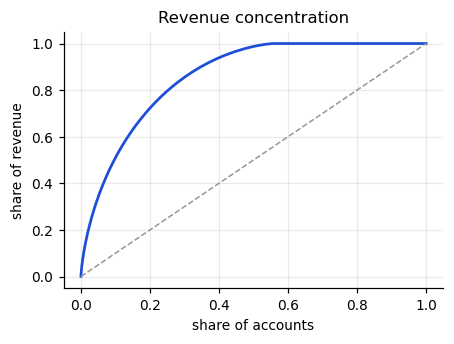

In [4]:
acct_rev = (trips.groupby("account_id")["pass_revenue"].sum()
            .reindex(all_accounts, fill_value=0).sort_values(ascending=False))

cum = acct_rev.cumsum() / acct_rev.sum()
share_of_accounts = np.arange(1, len(cum) + 1) / len(cum)

for pct in [0.01, 0.05, 0.10, 0.20, 0.50]:
    # max(..., 0) guards small populations where pct * len(cum) < 1, which
    # would otherwise index cum.iloc[-1] instead of raising.
    i = max(int(pct * len(cum)) - 1, 0)
    print(f"top {pct:>5.0%} of accounts  ->  {cum.iloc[i]:>6.1%} of pass revenue")

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.plot(share_of_accounts, cum.values, color=ACCENT, linewidth=1.8)
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("share of accounts")
ax.set_ylabel("share of revenue")
ax.set_title("Revenue concentration")
plt.tight_layout()
plt.show()

### 1.4 Macro and seasonality should be visible

Trip volume must track the macro index. This is what makes the forward simulation's correlated draws meaningful — if volume were independent of the economy here, modelling macro scenarios later would be theatre.

corr(trip volume, macro index)   = 0.892
corr(trip volume, seasonality)   = 0.492
corr(revenue, trip volume)       = 0.997


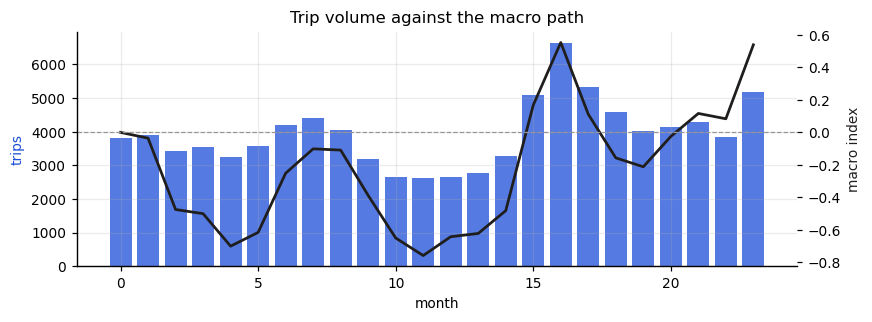

In [5]:
monthly = (trips.groupby("month")
           .agg(trips=("trip_id", "size"), revenue=("pass_revenue", "sum"))
           .reset_index().merge(macro, on="month"))

print(f"corr(trip volume, macro index)   = {monthly.trips.corr(monthly.macro_index):.3f}")
print(f"corr(trip volume, seasonality)   = {monthly.trips.corr(monthly.seasonality):.3f}")
print(f"corr(revenue, trip volume)       = {monthly.revenue.corr(monthly.trips):.3f}")

fig, ax1 = plt.subplots(figsize=(8, 3))
ax1.bar(monthly.month, monthly.trips, color=ACCENT, alpha=0.75, label="trips")
ax1.set_xlabel("month")
ax1.set_ylabel("trips", color=ACCENT)

ax2 = ax1.twinx()
ax2.plot(monthly.month, monthly.macro_index, color=INK, linewidth=1.8, label="macro index")
ax2.axhline(0, color=MUTED, linewidth=0.8, linestyle="--")
ax2.set_ylabel("macro index", color=INK)
ax2.grid(False)

ax1.set_title("Trip volume against the macro path")
plt.tight_layout()
plt.show()

---
## 2 · Is the label boundary readable from the data?

This is the decision that matters most. In production the five states are **not observed** — they have to be reconstructed from what is measurable:

| Observable | What it distinguishes |
|---|---|
| `days_bought == 0` | bought nothing: **substitutes** or **leaves** |
| `days_bought / days_traveled` | how much of the trip was covered |
| `lines_active / lines_traveling` | how much of the party was covered |

The hard boundary is **reduces vs unchanged**. Both bought the pass; the question is how far below full coverage counts as a deliberate reduction rather than incidental variation.

If the coverage ratio is bimodal — a spike at 1.0 and a separate spread below it — the threshold reads off the valley between them. If it is a smooth continuum, no threshold is defensible and the state has to be treated probabilistically instead.

Day coverage among trips that bought the pass
count    85486.000
mean         0.942
std          0.213
min          0.038
5%           0.500
25%          1.000
50%          1.000
75%          1.000
95%          1.167
max          3.500

exactly 1.0 : 72.3%
above 1.0   : 7.1%   (bought more days than travelled)
below 1.0   : 20.6%


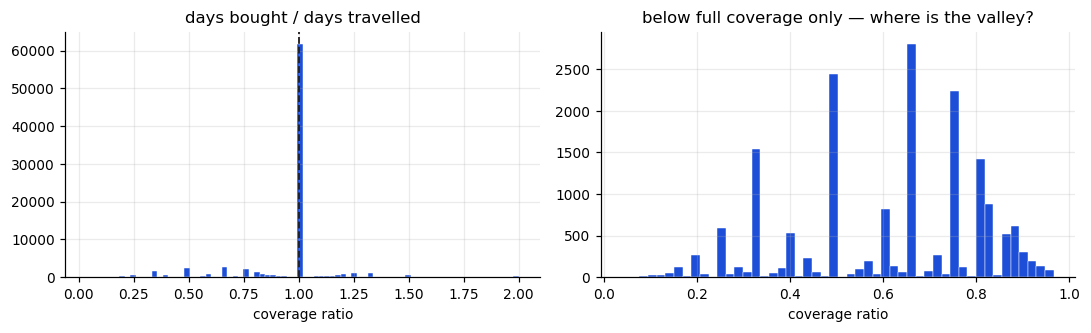

In [6]:
bought = trips[trips["days_bought"] > 0].copy()
bought["day_coverage"] = bought["days_bought"] / bought["days_traveled"]
bought["line_coverage"] = bought["lines_active"] / bought["lines_traveling"]

print("Day coverage among trips that bought the pass")
print(bought["day_coverage"].describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_string())
print(f"\nexactly 1.0 : {(bought.day_coverage == 1).mean():.1%}")
print(f"above 1.0   : {(bought.day_coverage > 1).mean():.1%}   (bought more days than travelled)")
print(f"below 1.0   : {(bought.day_coverage < 1).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.1))

axes[0].hist(bought["day_coverage"].clip(0, 2), bins=80, color=ACCENT,
             edgecolor="white", linewidth=0.3)
axes[0].axvline(1.0, color=INK, linewidth=1.2, linestyle="--")
axes[0].set_title("days bought / days travelled")
axes[0].set_xlabel("coverage ratio")

axes[1].hist(bought.loc[bought.day_coverage < 1, "day_coverage"], bins=50,
             color=ACCENT, edgecolor="white", linewidth=0.3)
axes[1].set_title("below full coverage only — where is the valley?")
axes[1].set_xlabel("coverage ratio")

plt.tight_layout()
plt.show()

### 2.1 Testing candidate thresholds against the truth

Because this is synthetic data, the true state is known. That allows something impossible with real data: **scoring the labelling rule itself.**

Each candidate rule below is applied as it would be in production — using only observables — and then compared against `state`. In production this comparison is impossible, which is exactly why establishing it here is worth the effort.

**Three rules are tested, not one.** A coverage *ratio* conflates trip lengths: one day short on a three-day trip is a 0.67 ratio and is almost certainly incidental, while one day short on a ten-day trip is 0.90 and probably also incidental. A single ratio cutoff cannot separate those, so two alternatives are tried alongside it:

| Rule | Reduces when |
|---|---|
| **ratio** | coverage falls below a cutoff |
| **absolute** | a fixed number of days went unbought, regardless of trip length |
| **combined** | materially short in days *and* below the ratio cutoff |

**Accuracy is the wrong criterion.** `unchanged` dominates the population, so a rule that labels almost nothing as `reduces` scores well while missing most of the real reductions. F1 on the minority class is reported alongside it and is what the choice should follow.

In [7]:
def apply_rule(df, day_thresh, line_thresh=0.999, rule="ratio", days_short=2):
    """Reconstruct states from observables only — no use of the true state.

    Note: 'substitutes' and 'leaves' are indistinguishable at trip level
    (both simply buy nothing). Separating them requires account-level
    evidence of departure, so they are pooled here as 'no_purchase'.
    """
    days = df["days_bought"] / df["days_traveled"]
    lines = df["lines_active"] / df["lines_traveling"].clip(lower=1)

    short = df["days_traveled"] - df["days_bought"]

    if rule == "ratio":
        is_reduce = days < day_thresh
    elif rule == "absolute":
        # A fixed number of days short, regardless of trip length
        is_reduce = short >= days_short
    elif rule == "combined":
        # Must be both materially short in days AND below the ratio cutoff.
        # One day short is incidental on any trip length; two days short on a
        # short trip is a decision.
        is_reduce = (short >= days_short) & (days < day_thresh)
    else:
        raise ValueError(rule)

    # Order matters: no_purchase is applied last so it overrides is_reduce for
    # days_bought == 0 rows (which is_reduce would otherwise also catch).
    out = pd.Series("unchanged", index=df.index, dtype=object)
    out[days > 1.0] = "increases"
    out[is_reduce | (lines < line_thresh)] = "reduces"
    out[df["days_bought"] == 0] = "no_purchase"
    return out


truth_pooled = trips["state"].replace({"substitutes": "no_purchase", "leaves": "no_purchase"})

def score(pred, label):
    tp = ((pred == "reduces") & (truth_pooled == "reduces")).sum()
    return {
        "rule": label,
        "accuracy": (pred == truth_pooled).mean(),
        "recall": tp / max((truth_pooled == "reduces").sum(), 1),
        "precision": tp / max((pred == "reduces").sum(), 1),
        "share labelled": (pred == "reduces").mean(),
    }


rows = []
rule_params = {}
for t in [0.999, 0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.50, 0.40]:
    label = f"ratio < {t}"
    rule_params[label] = dict(day_thresh=t, rule="ratio")
    rows.append(score(apply_rule(trips, t, rule="ratio"), label))
for d in [1, 2, 3, 4]:
    label = f"short >= {d}d"
    rule_params[label] = dict(day_thresh=1.0, rule="absolute", days_short=d)
    rows.append(score(apply_rule(trips, 1.0, rule="absolute", days_short=d), label))
for d in [2, 3]:
    for t in [0.95, 0.85, 0.75]:
        label = f"short >= {d}d and ratio < {t}"
        rule_params[label] = dict(day_thresh=t, rule="combined", days_short=d)
        rows.append(score(apply_rule(trips, t, rule="combined", days_short=d), label))

res = pd.DataFrame(rows).set_index("rule").round(4)
res["f1"] = (2 * res.precision * res.recall / (res.precision + res.recall)).round(4)
print(res.to_string())

true_share = (truth_pooled == "reduces").mean()
print(f"\nTrue share reducing: {true_share:.4f}")
print(f"Best F1:      {res.f1.idxmax()}  (F1 {res.f1.max():.3f})")
print(f"Best accuracy: {res.accuracy.idxmax()}  ({res.accuracy.max():.1%})")

# Accuracy is dominated by 'unchanged' and rewards under-labelling. F1 on the
# minority class is the honest criterion here.
# Chosen on F1 and on the asymmetry argument above: of the top F1 rules, this
# one has the higher recall, and missing a real reduction is the more costly
# error than over-labelling one — so it's not simply the argmax of F1.
# Derived from `rule_params` (not hand-typed) so BEST_RULE always matches an
# actual row above, and checked against the F1 ranking so a change in the
# underlying data that drops it out of contention doesn't pass silently.
BEST_LABEL = "ratio < 0.7"
assert BEST_LABEL in res.index, f"{BEST_LABEL!r} not among the candidate rules tested above"
BEST_RULE = rule_params[BEST_LABEL]
best_rank = int(res.f1.rank(ascending=False)[BEST_LABEL])
print(f"\nChosen rule: {BEST_LABEL}  ->  {BEST_RULE}")
print(f"F1 = {res.loc[BEST_LABEL, 'f1']:.3f}, precision = {res.loc[BEST_LABEL, 'precision']:.3f}, "
      f"recall = {res.loc[BEST_LABEL, 'recall']:.3f}  (rank {best_rank} of {len(res)} by F1)")
assert best_rank <= 3, (
    f"{BEST_LABEL!r} dropped to rank {best_rank} by F1 — the asymmetric-cost "
    "argument for choosing it over the top F1 rule no longer holds; re-pick BEST_RULE."
)

                              accuracy  recall  precision  share labelled      f1
rule                                                                             
ratio < 0.999                   0.9156  0.9523     0.5762          0.1864  0.7180
ratio < 0.95                    0.9165  0.9522     0.5789          0.1856  0.7200
ratio < 0.9                     0.9223  0.9491     0.5981          0.1790  0.7338
ratio < 0.85                    0.9311  0.9354     0.6314          0.1671  0.7539
ratio < 0.8                     0.9444  0.8870     0.7002          0.1429  0.7826
ratio < 0.7                     0.9507  0.7898     0.7772          0.1147  0.7834
ratio < 0.6                     0.9487  0.6064     0.9086          0.0753  0.7274
ratio < 0.5                     0.9277  0.3891     0.9277          0.0473  0.5483
ratio < 0.4                     0.9194  0.3157     0.9124          0.0390  0.4691
short >= 1d                     0.9156  0.9523     0.5762          0.1864  0.7180
short >= 2d     

In [8]:
# Where the chosen rule gets it wrong — the errors matter more than the accuracy
pred = apply_rule(trips, **BEST_RULE)
confusion = pd.crosstab(truth_pooled, pred, normalize="index").round(3)
confusion.index.name = "true state"
confusion.columns.name = "labelled as"
print(confusion.to_string())

labelled as  increases  no_purchase  reduces  unchanged
true state                                             
increases          1.0          0.0    0.000      0.000
no_purchase        0.0          1.0    0.000      0.000
reduces            0.0          0.0    0.790      0.210
unchanged          0.0          0.0    0.035      0.965


**Reading the confusion table.** Two failure modes matter and they are not symmetric.

- **Reduces labelled unchanged** understates price damage. The model learns that customers tolerate increases better than they do, and the revenue case is optimistic.
- **Unchanged labelled reduces** overstates it, and the recommendation becomes needlessly timid.

Given the decision at stake — a price increase that leadership is already nervous about — the second error is the safer one to make. Worth choosing the threshold accordingly rather than purely maximising accuracy.

**On `no_purchase`.** Substitutes and leaves cannot be separated at trip level: both look like an absence of purchase. They are pooled here deliberately. Splitting them requires account-level evidence of departure, which belongs in the modelling notebook, not the labelling rule.

---
## 3 · Is there enough price variation — per segment?

A price response can only be estimated where the price actually moved. Checked overall this almost always looks fine; checked per segment it frequently does not, and a segment whose sensitivity cannot be estimated will silently inherit the population average.

That failure is invisible in model metrics and shows up only when a pricing decision is made for a group the model never had evidence about.

In [9]:
print("Overall price exposure")
print(trips["price_multiplier"].value_counts(normalize=True).sort_index().round(4).to_string())
print(f"\nShare of trips off the standard rate: {(trips.price_multiplier != 1.0).mean():.1%}")

trips["party_band"] = pd.cut(trips["lines_traveling"], [0, 1, 2, 10],
                             labels=["solo", "pair", "3+"])
trips["segment"] = (pd.Series(np.where(trips.is_business, "business", "consumer"),
                               index=trips.index)
                      .str.cat(trips.party_band.astype(str), sep=" / "))

variation = trips.pivot_table(index="segment", columns="price_multiplier",
                              values="trip_id", aggfunc="count").fillna(0).astype(int)
variation["total"] = variation.sum(axis=1)
variation["off-standard %"] = (1 - variation[1.0] / variation["total"]).round(3)
print("\nTrips by segment and price multiplier")
print(variation.to_string())

Overall price exposure
price_multiplier
0.90    0.0651
0.95    0.0819
1.00    0.6711
1.10    0.1087
1.20    0.0732

Share of trips off the standard rate: 32.9%

Trips by segment and price multiplier
price_multiplier   0.9  0.95    1.0   1.1   1.2  total  off-standard %
segment                                                               
business / 3+      299   436   3262   525   406   4928           0.338
business / pair    159   229   1822   321   213   2744           0.336
business / solo   2994  3730  31087  5036  3394  46241           0.328
consumer / 3+      397   473   3946   625   437   5878           0.329
consumer / pair    584   715   5870   922   594   8685           0.324
consumer / solo   1712  2153  17394  2833  1872  25964           0.330


In [10]:
# Minimum cell size for a segment's response to be estimable at all
MIN_CELL = 300

cells = (trips.groupby(["segment", "price_multiplier"]).size()
         .rename("n").reset_index())
thin = cells[cells.n < MIN_CELL]

if thin.empty:
    print(f"All segment x price cells have at least {MIN_CELL} trips.")
else:
    print(f"Cells below {MIN_CELL} trips — sensitivity here will not be estimable:\n")
    print(thin.sort_values("n").to_string(index=False))

# Does the naive elasticity signal actually appear per segment?
print("\nNo-purchase rate by segment and price — the raw signal the model must find")
signal = trips.pivot_table(index="segment", columns="price_multiplier",
                           values="days_bought", aggfunc=lambda s: (s == 0).mean()).round(3)
print(signal.to_string())

Cells below 300 trips — sensitivity here will not be estimable:

        segment  price_multiplier   n
business / pair              0.90 159
business / pair              1.20 213
business / pair              0.95 229
  business / 3+              0.90 299

No-purchase rate by segment and price — the raw signal the model must find
price_multiplier   0.90   0.95   1.00   1.10   1.20
segment                                            
business / 3+     0.070  0.060  0.067  0.078  0.116
business / pair   0.082  0.066  0.074  0.090  0.103
business / solo   0.057  0.064  0.067  0.080  0.098
consumer / 3+     0.101  0.104  0.117  0.168  0.224
consumer / pair   0.104  0.130  0.122  0.172  0.200
consumer / solo   0.085  0.115  0.117  0.161  0.201


### 3.1 The confounding is real — and that is intentional

The price multiplier was assigned by region and period, not at random. Heavy travellers, particular destinations and the higher-price windows overlap, so a naive comparison of outcomes across price levels attributes those differences to price.

The check below shows how much. If the raw difference and the within-segment difference disagree, the modelling notebook must control for it — and this is the evidence for why.

In [11]:
high = trips[trips.price_multiplier >= 1.10]
base = trips[trips.price_multiplier == 1.0]

print("Naive comparison, high price vs standard")
print(f"  business share    {high.is_business.mean():.3f}  vs  {base.is_business.mean():.3f}")
print(f"  europe/apac share {high.region.isin(['europe','apac']).mean():.3f}  vs  "
      f"{base.region.isin(['europe','apac']).mean():.3f}")
print(f"  avg days          {high.days_traveled.mean():.2f}  vs  {base.days_traveled.mean():.2f}")

raw = high.days_bought.eq(0).mean() - base.days_bought.eq(0).mean()
print(f"\nRaw difference in no-purchase rate: {raw:+.4f}")

within = []
for (seg_, reg), g in trips.groupby(["segment", "region"]):
    h = g[g.price_multiplier >= 1.10]
    b = g[g.price_multiplier == 1.0]
    if len(h) >= 100 and len(b) >= 100:
        within.append((h.days_bought.eq(0).mean() - b.days_bought.eq(0).mean(), len(h) + len(b)))

if within:
    diffs, weights = zip(*within)
    print(f"Within segment x region:            {np.average(diffs, weights=weights):+.4f}")
    print(f"Confounding accounts for:           {raw - np.average(diffs, weights=weights):+.4f}")

Naive comparison, high price vs standard
  business share    0.576  vs  0.571
  europe/apac share 0.884  vs  0.428
  avg days          5.49  vs  5.50

Raw difference in no-purchase rate: +0.0383
Within segment x region:            +0.0225
Confounding accounts for:           +0.0158


---
## 4 · Recovering the truth

A final check available only with synthetic data: does observable behaviour actually carry the latent sensitivity signal?

Accounts are bucketed by their true sensitivity decile and their observed behaviour compared. If the most and least sensitive deciles behave identically at higher prices, no model will separate them and the generator needs stronger signal. If they separate cleanly, the signal is present and any later failure to find it is a modelling problem.

**Read value per account, not per trip.** Sensitivity is correlated with travel frequency, and the least sensitive accounts are business accounts whose trips are short and solo. Per-trip revenue therefore runs *inverse* to insensitivity, which inverts the finding. Any claim that the upside sits with high-value, price-insensitive customers has to be made per account.

Behaviour at elevated prices, by TRUE sensitivity decile
(decile 0 = most sensitive)

                    trips  no_purchase  avg_coverage  avg_revenue
sensitivity_decile                                               
0                     807        0.202         4.836       73.435
1                     825        0.189         5.161       75.288
2                     842        0.196         5.068       72.511
3                     898        0.179         5.158       75.302
4                    1004        0.176         4.904       71.725
5                    1154        0.162         5.175       75.762
6                    1324        0.142         4.730       67.228
7                    2027        0.114         4.151       58.316
8                    3186        0.102         3.748       50.431
9                    5111        0.085         3.535       46.224

Value per account by sensitivity decile — the unit a price decision uses
                    accounts  trips_per_account 

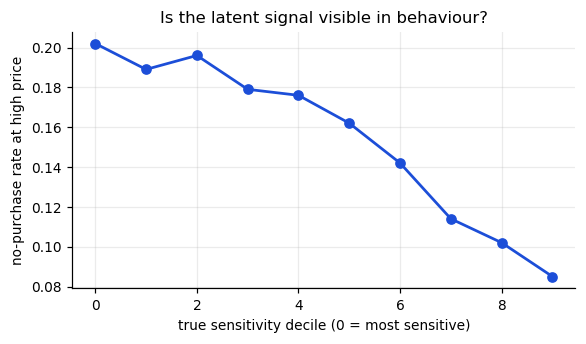


Spread, most vs least sensitive decile: +0.117
Signal is present and learnable.


In [12]:
gt = trips.merge(ground_truth[["account_id", "sensitivity_decile"]], on="account_id")
high_price = gt[gt.price_multiplier >= 1.10]

by_decile = high_price.groupby("sensitivity_decile").agg(
    trips=("trip_id", "size"),
    no_purchase=("days_bought", lambda s: (s == 0).mean()),
    avg_coverage=("days_bought", "mean"),
    avg_revenue=("pass_revenue", "mean"),
).round(3)
print("Behaviour at elevated prices, by TRUE sensitivity decile")
print("(decile 0 = most sensitive)\n")
print(by_decile.to_string())

# Per-trip revenue is confounded: the least sensitive accounts are business, and
# business trips are short and solo. Value has to be read per ACCOUNT.
# Uses `gt` (the full window, not just `high_price`) — deliberately: the value
# a price decision cares about is what an account is worth overall, not just
# what it spends during the elevated-price trips being diagnosed above.
acct_decile = (gt.groupby(["sensitivity_decile", "account_id"])
               .agg(trips=("trip_id", "size"), revenue=("pass_revenue", "sum"))
               .groupby("sensitivity_decile").agg(
                   accounts=("trips", "size"),
                   trips_per_account=("trips", "mean"),
                   revenue_per_account=("revenue", "mean"),
               ).round(2))
print("\nValue per account by sensitivity decile — the unit a price decision uses")
print(acct_decile.to_string())

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(by_decile.index, by_decile.no_purchase, marker="o", color=ACCENT, linewidth=1.8)
ax.set_xlabel("true sensitivity decile (0 = most sensitive)")
ax.set_ylabel("no-purchase rate at high price")
ax.set_title("Is the latent signal visible in behaviour?")
plt.tight_layout()
plt.show()

spread = by_decile.no_purchase.iloc[0] - by_decile.no_purchase.iloc[-1]
print(f"\nSpread, most vs least sensitive decile: {spread:+.3f}")
print("Signal is present and learnable." if abs(spread) > 0.05
      else "Signal too weak — increase sensitivity dispersion in notebook 01.")

---
## Decisions this notebook produces

Record these before moving on; the modelling notebook depends on all four.

| Decision | Set by |
|---|---|
| **Day coverage threshold** for reduces vs unchanged | §2.1, adjusted toward over-labelling reduces rather than under |
| **`substitutes` and `leaves` are pooled** at trip level | §2.1 — inseparable without account-level departure evidence |
| **Segments with thin price variation** | §3, flagged as not estimable rather than silently averaged |
| **Confounding must be controlled** | §3.1 — raw and within-segment differences disagree |

### Fix in notebook 01 if

- Party size or duration looks symmetric rather than skewed.
- Revenue concentration is close to uniform.
- Trip volume does not track the macro index.
- The sensitivity-decile spread in §4 is under ~5 points.

### Next

`03_state_model.ipynb` — multiclass model on the reconstructed labels, split by time rather than at random, with class weighting for the rare states and calibration curves before any of it feeds a simulation.